# 2주차: Decision Tree

와인 데이터를 이용해서 Decision Tree 모델 실습

## 라이브러리

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## 데이터 로드

In [2]:
red_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/winequality-red.csv'
white_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/winequality-white.csv'

red_wine = pd.read_csv(red_url, sep=';')
white_wine = pd.read_csv(white_url, sep=';')

In [4]:
red_wine['color'] = 1.
white_wine['color'] = 0.

data = pd.concat([red_wine, white_wine])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 710.6 KB


In [6]:
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,1.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0.0
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0.0
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0.0
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,0.0


### 와인 데이터셋 컬럼 설명

*   `fixed acidity`: 고정 산도 (와인의 신맛에 영향)
*   `volatile acidity`: 휘발성 산도 (높으면 식초와 같은 신맛이 강해짐)
*   `citric acid`: 시트르산 함량 (신선한 신맛을 더함)
*   `residual sugar`: 잔류 당분 (와인의 단맛을 결정)
*   `chlorides`: 염화물 함량 (와인의 짠맛에 영향)
*   `free sulfur dioxide`: 자유 이산화황 (산화 및 미생물 번식 방지)
*   `total sulfur dioxide`: 총 이산화황 (첨가된 총 이산화황의 양)
*   `density`: 밀도 (당분과 알코올 함량에 영향)
*   `pH`: pH (와인의 산성도, 낮을수록 산성)
*   `sulphates`: 황산염 함량 (쓴맛과 항산화 작용)
*   `alcohol`: 알코올 함량 (와인의 도수)
*   `quality`: 품질 점수 (높을수록 좋은 품질)
*   `color`: 와인의 색깔 (레드 와인/화이트 와인 구분)

In [7]:
# describe() 메서드 사용
description = data.describe()
print(description) # color가 target

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000             1.000000         

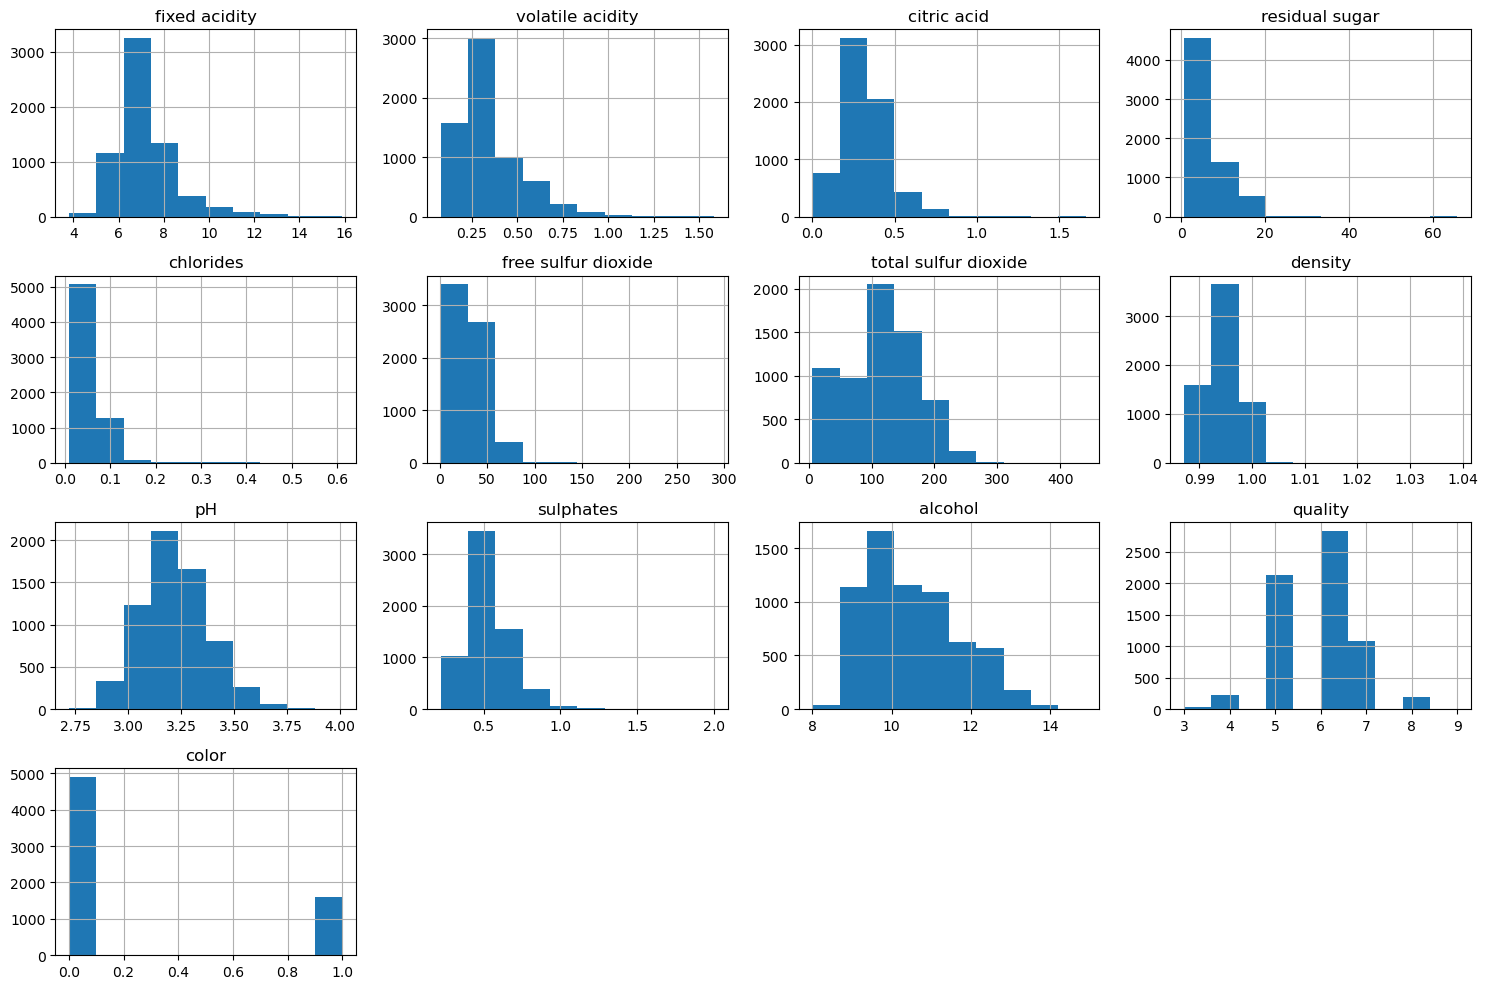

In [8]:
# Histogram (각 컬럼별로 subplot 생성)
data.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

## Decision Tree 기본

In [9]:
data['quality_group'] = pd.qcut(data['quality'], 3, labels=[0, 1, 2]) # quality 연속 변수를 3개의 클래스로 구분해줌 -> y값
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color,quality_group
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1.0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1.0,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,1.0,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1.0,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0.0,1
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0.0,0
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0.0,1
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,0.0,2


In [10]:
# 데이터 분할
X = data.drop(['quality', 'quality_group'], axis=1)
y = data['quality_group']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# 1. 기본적인 DecisionTree 학습, 트리 시각화, 테스트 정확도
dt_basic = DecisionTreeClassifier()
dt_basic.fit(X_train, y_train)

DecisionTreeClassifier()

In [12]:
y_pred_basic = dt_basic.predict(X_test)
accuracy_basic = accuracy_score(y_test, y_pred_basic)

In [13]:
print("기본 DecisionTree 테스트 정확도:", accuracy_basic)

기본 DecisionTree 테스트 정확도: 0.6307692307692307


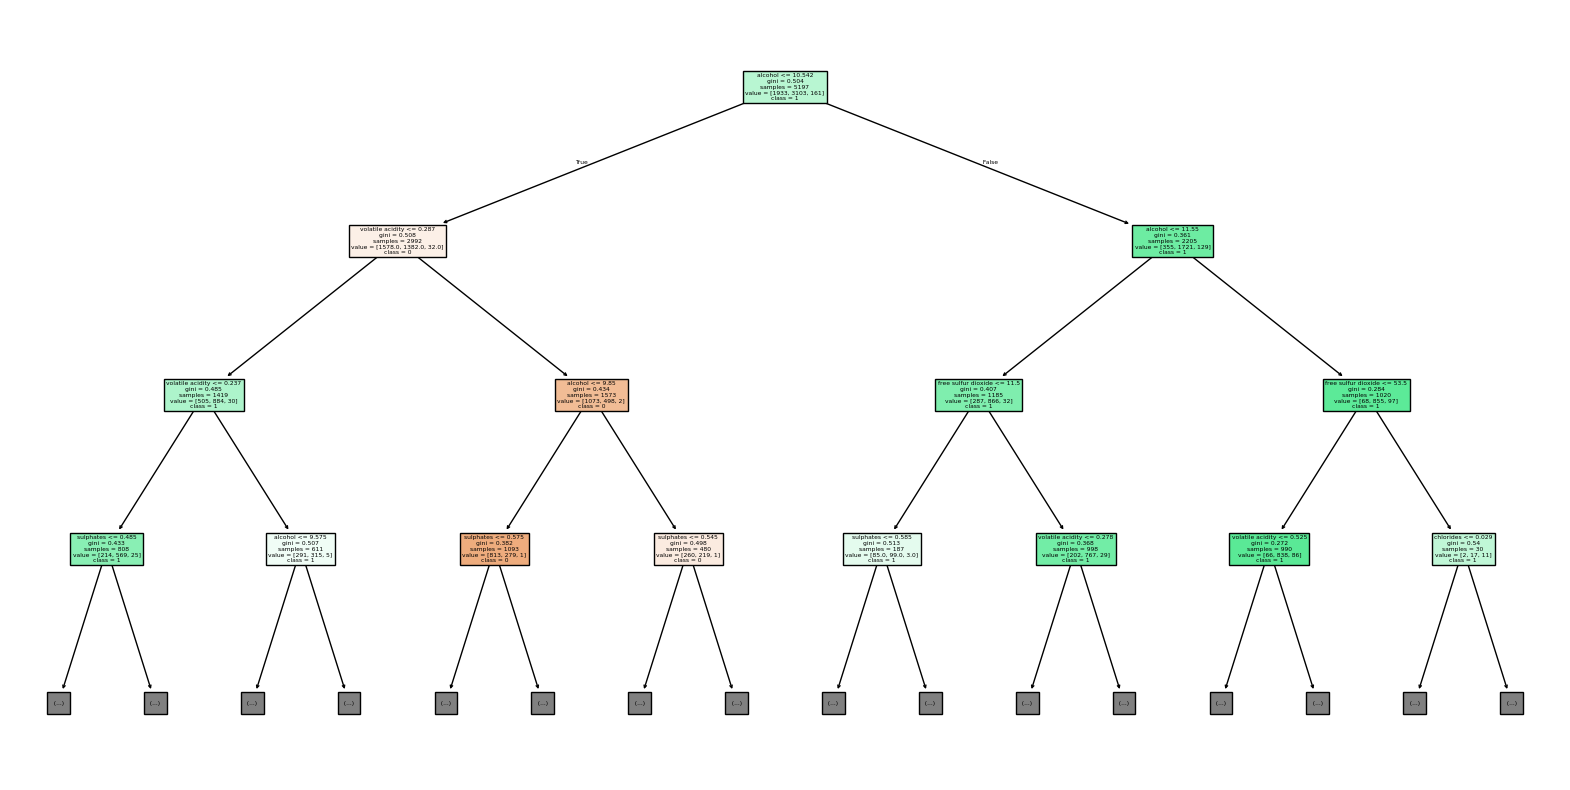

In [ ]:
plt.figure(figsize=(20, 10)) # plot 크기 조절
plot_tree(dt_basic, filled=True, feature_names=X.columns, class_names=np.unique(y).astype(str), max_depth=3) # class_names 추가 및 max_depth 제한
plt.show()

## 노드 수에 따른 정확도 변화

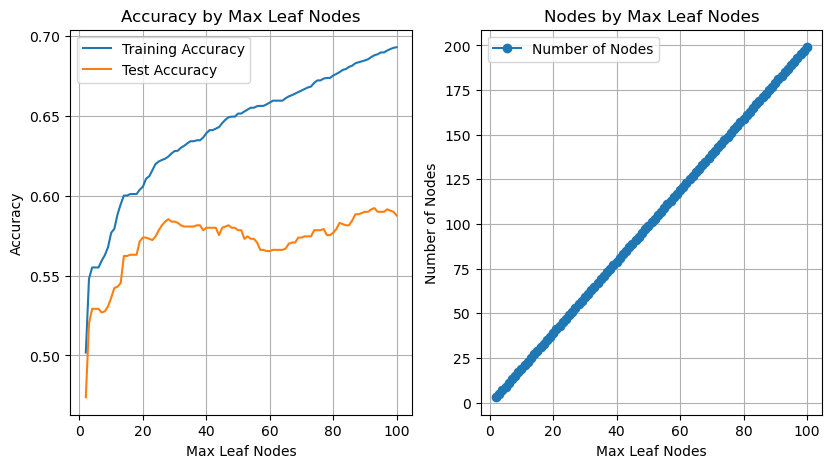

In [16]:
# 2. max_leaf_nodes 조절에 따른 정확도 및 노드 수 변화 -> overfitting을 막기 위함
train_accuracies = []
test_accuracies = []
node_counts = []
leaf_nodes = range(2, 101, 1)

for leaf in leaf_nodes:
    dt = DecisionTreeClassifier(max_leaf_nodes=leaf, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)
    train_accuracies.append(accuracy_score(y_train, y_pred_train))
    test_accuracies.append(accuracy_score(y_test, y_pred_test))
    node_counts.append(dt.tree_.node_count)

# 그래프 그리기
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(leaf_nodes, train_accuracies, label='Training Accuracy')
plt.plot(leaf_nodes, test_accuracies, label='Test Accuracy')
plt.xlabel('Max Leaf Nodes')
plt.ylabel('Accuracy')
plt.title('Accuracy by Max Leaf Nodes')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(leaf_nodes, node_counts, marker='o', linestyle='-', label='Number of Nodes')
plt.xlabel('Max Leaf Nodes')
plt.ylabel('Number of Nodes')
plt.title('Nodes by Max Leaf Nodes')
plt.legend()
plt.grid(True)

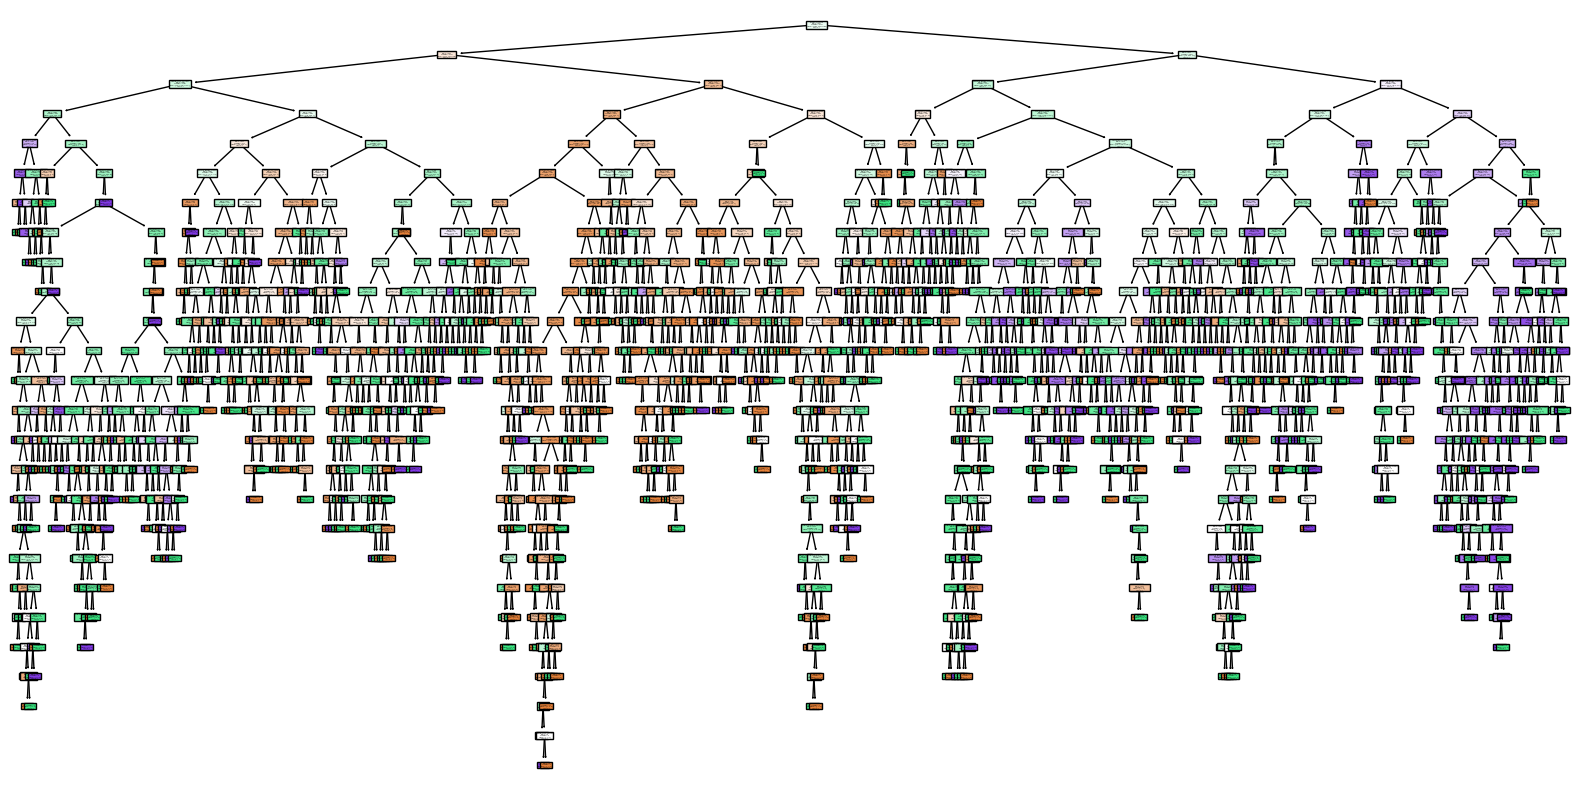

In [17]:
plt.figure(figsize=(20, 10)) # plot 크기 조절
plot_tree(dt_basic, filled=True, feature_names=X.columns, class_names=np.unique(y).astype(str))
plt.show()

## 하이퍼 파라미터

In [18]:
# 데이터 분할
X = data.drop(['color', 'quality_group'], axis=1)
y = data['color'] # target -> color
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
dt_basic = DecisionTreeClassifier()
dt_basic.fit(X_train, y_train)

y_pred_basic = dt_basic.predict(X_test)
accuracy_basic = accuracy_score(y_test, y_pred_basic)

print("기본 DecisionTree 테스트 정확도:", accuracy_basic)

기본 DecisionTree 테스트 정확도: 0.9830769230769231


최적 하이퍼 파라미터: {'criterion': 'entropy', 'max_depth': 17, 'max_leaf_nodes': 85, 'min_samples_leaf': 1, 'min_samples_split': 4, 'splitter': 'random'}
최적 하이퍼 파라미터의 정확도: 0.9865314281483677
최적 모델의 테스트 정확도: 0.9823076923076923


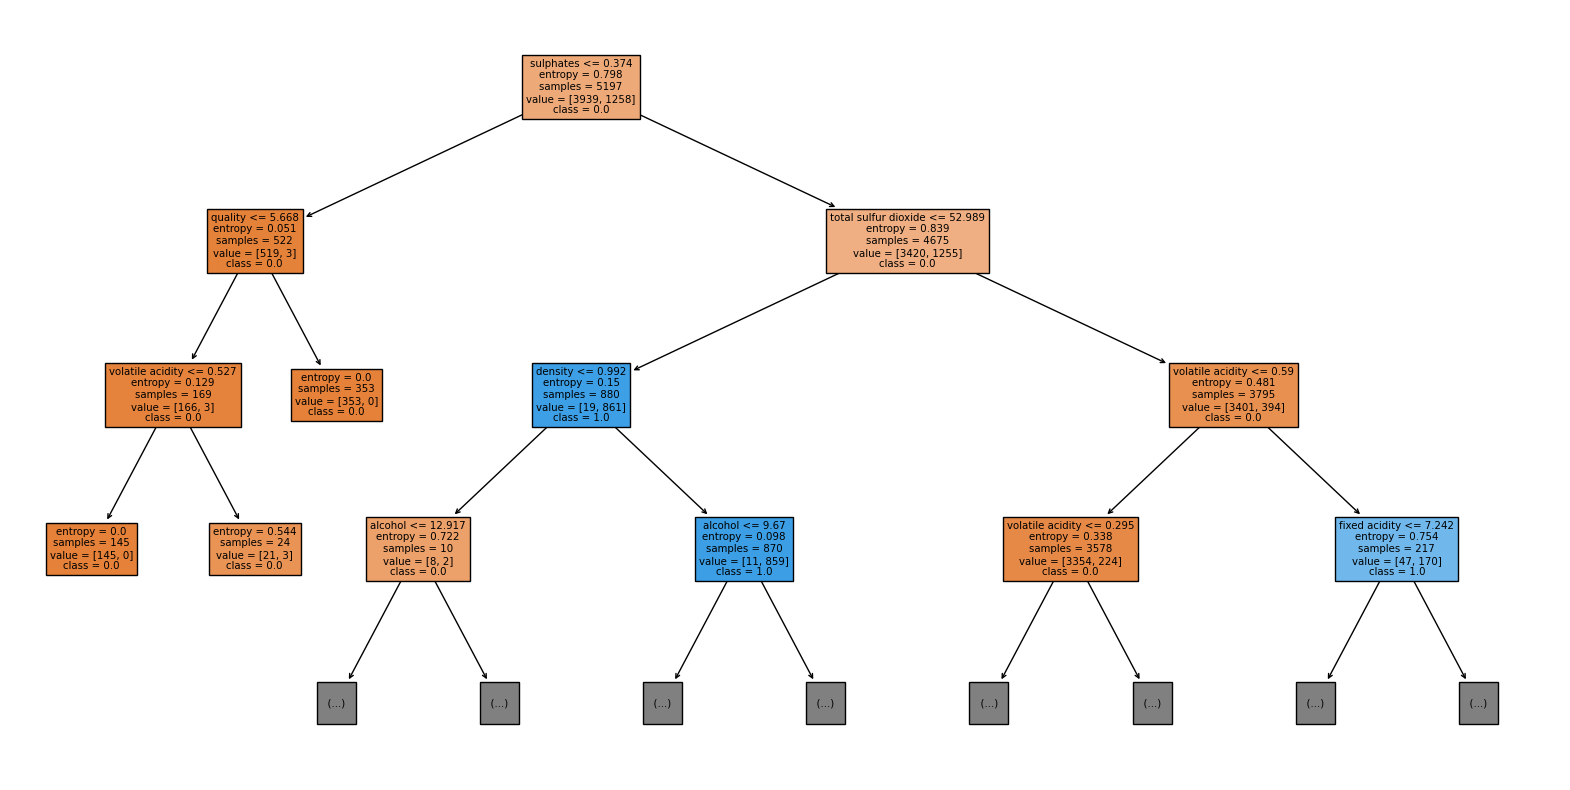

In [20]:
# 3. GridSearchCV로 최적의 하이퍼 파라미터 서치 후 트리 시각화, 정확도 확인
param_grid = {
    'max_depth': range(3, 21, 2),
    'min_samples_split': range(2, 21, 2), # 노드의 최소 샘플 개수
    'min_samples_leaf': range(1, 6, 2), # 분할 이후의 리프의 최소 샘플 개수
    'max_leaf_nodes': range(10, 101, 5),
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random']
}

dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("최적 하이퍼 파라미터:", grid_search.best_params_)
print("최적 하이퍼 파라미터의 정확도:", grid_search.best_score_)

best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

print("최적 모델의 테스트 정확도:", accuracy_best)

plt.figure(figsize=(20, 10))
plot_tree(best_dt, filled=True, feature_names=X.columns, class_names=np.unique(y).astype(str), max_depth=3)
plt.show()

# 과제

자동차 평가 데이터 베이스를 이용한 Decision Tree 실습

Bohanec, M. (1988). Car Evaluation [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5JP48.

In [29]:

import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
car_evaluation = fetch_ucirepo(id=19)

# data (as pandas dataframes)
X = car_evaluation.data.features
y = car_evaluation.data.targets

In [13]:
X

,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med
...,...,...,...,...,...,...
1723,low,low,5more,more,med,med
1724,low,low,5more,more,med,high
1725,low,low,5more,more,big,low
1726,low,low,5more,more,big,med


In [27]:
y.iloc[:, 0].unique()

array(['unacc', 'acc', 'vgood', 'good'], dtype=object)

In [14]:
print(X.buying.unique()) 
print(X.maint.unique())
print(X.doors.unique())
print(X.persons.unique())
print(X.lug_boot.unique())
print(X.safety.unique()) # 모든 feature가 범주형 -> 6개의 범주형으로 y 4개의 class로 분류하는 과제

['vhigh' 'high' 'med' 'low']
['vhigh' 'high' 'med' 'low']
['2' '3' '4' '5more']
['2' '4' 'more']
['small' 'med' 'big']
['low' 'med' 'high']


In [5]:
y

,class
0,unacc
1,unacc
2,unacc
3,unacc
4,unacc
...,...
1723,good
1724,vgood
1725,unacc
1726,good


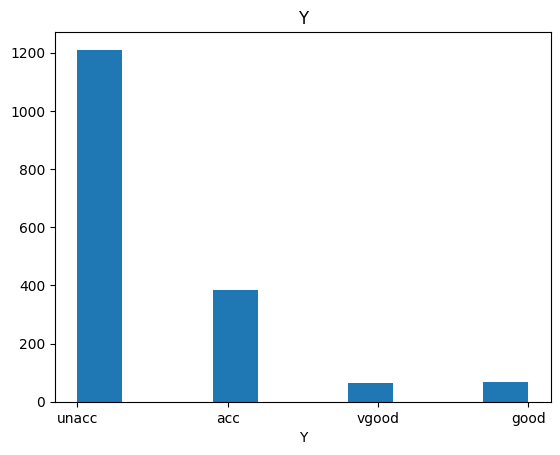

In [ ]:
import matplotlib.pyplot as plt

plt.hist(y)
plt.xlabel('Y')
plt.title('Y')
plt.show()

## 데이터셋 컬럼 설명

*   `buying`: 구매 가격
*   `maint`: 유지 보수 비용
*   `doors`: 문의 개수
*   `persons`: 탑승 가능 인원 수
*   `lug_boot`: 수납 공간 크기
*   `safety`: 안전 등급

## 1. Decision Tree 기본으로 성능 확인

In [66]:
# TODO: 데이터를 트레인 데이터와 테스트 데이터로 나눈 뒤 Decision Tree에 학습시켜서 테스트 데이터 정확도가 얼마나 나오는지 확인
# Tip: X값이 범주형일 경우 수치형으로 인코딩을 해줘야 합니다.

# Decision Tree bagging(복원 추출을 통한 aggregation) -> RF (Random forest) 

# 범주형 데이터를 수치형으로 인코딩 (Nominal -> 수치형)
print(X.head())

X_hot_encoded = pd.get_dummies(X) # get_dummies는 원핫 인코딩함.. 
print('----------')

print(X_hot_encoded.head())
print(X_hot_encoded.shape) # 컬럼 21개로 변함 .. label encoding 방식으로 해야겠다


from sklearn.preprocessing import LabelEncoder


label_encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col]) # X의 feature을 label인코딩
    label_encoders[col] = le


   buying  maint  doors  persons  lug_boot  safety
0       3      3      0        0         2       1
1       3      3      0        0         2       2
2       3      3      0        0         2       0
3       3      3      0        0         1       1
4       3      3      0        0         1       2
----------
   buying  maint  doors  persons  lug_boot  safety
0       3      3      0        0         2       1
1       3      3      0        0         2       2
2       3      3      0        0         2       0
3       3      3      0        0         1       1
4       3      3      0        0         1       2
(1728, 6)


/var/folders/8r/mn1jpmv918l0h950j1dz70wr0000gn/T/ipykernel_27407/3180452084.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col]) # X의 feature을 label인코딩
/var/folders/8r/mn1jpmv918l0h950j1dz70wr0000gn/T/ipykernel_27407/3180452084.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col]) # X의 feature을 label인코딩
/var/folders/8r/mn1jpmv918l0h950j1dz70wr0000gn/T/ipykernel_27407/3180452084.py:22: SettingWithCopyWarning: 
A value is trying to be set on a

In [67]:



# Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2) # 0.8:0.2 로 TT split

In [68]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(1382, 6) (346, 6)
(1382, 1) (346, 1)


In [69]:
X_train.head() # 라벨로 인코딩, tvt split 했다.

,buying,maint,doors,persons,lug_boot,safety
1603,1,2,3,1,2,2
1391,1,3,3,1,1,0
580,0,0,1,1,1,2
1315,1,3,0,2,2,2
415,3,1,3,1,2,2


In [70]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train) # 모델 학습

DecisionTreeClassifier()

In [71]:
y_pred = dt.predict(X_test)

accuracy_base = accuracy_score(y_test, y_pred)
print(f'기본 Decision Tree model의 성능은,{accuracy_base}')

기본 Decision Tree model의 성능은,0.976878612716763


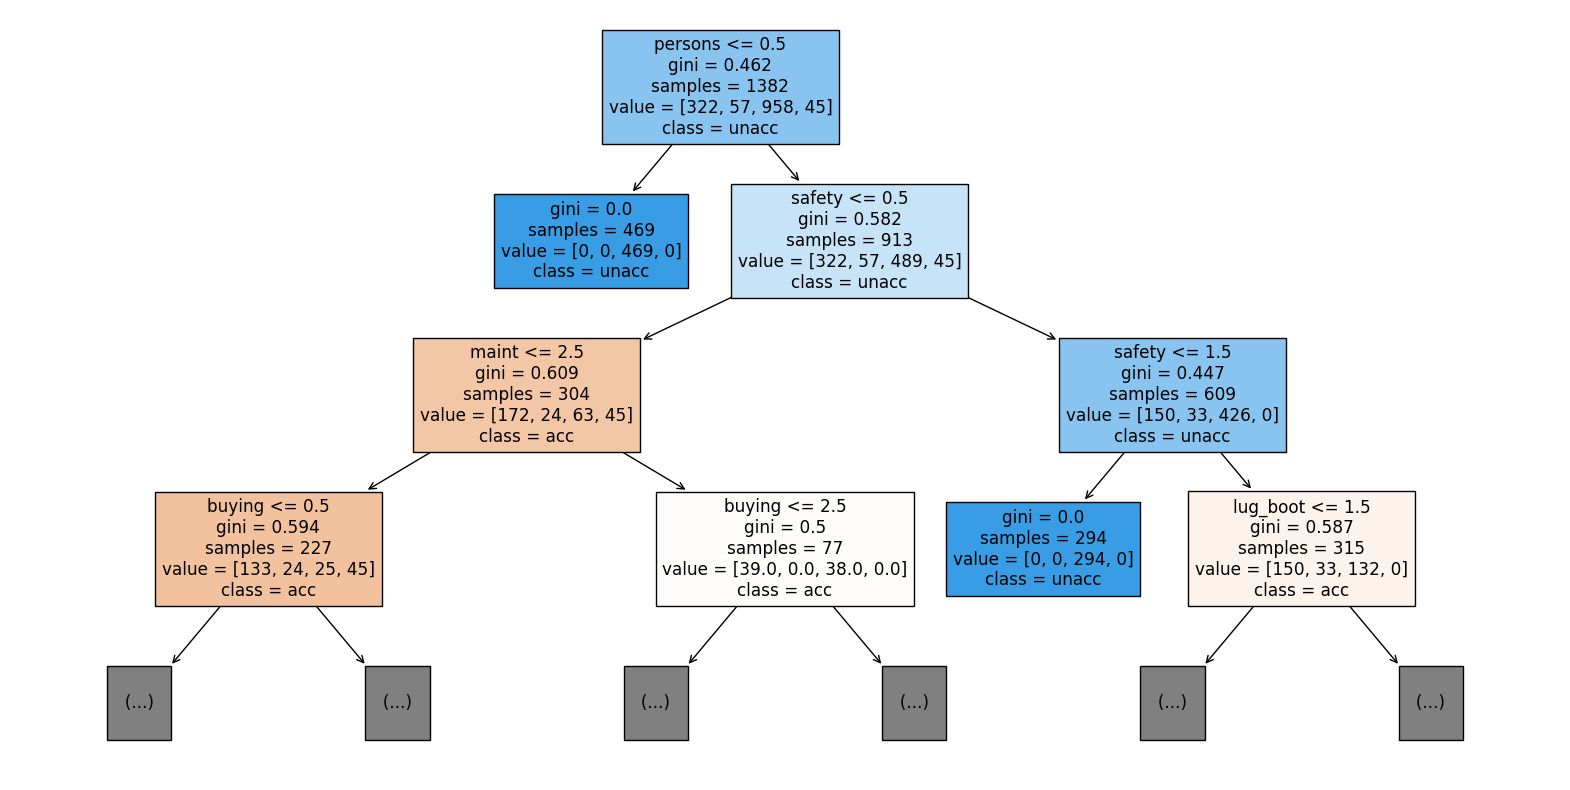

In [72]:
plt.figure(figsize=(20, 10)) # plot 크기 조절
plot_tree(dt, filled=True, feature_names=X_train.columns, class_names=np.unique(y).astype(str), max_depth=3) # class_names 추가 및 max_depth 제한
plt.show()

## 2. 최적의 하이퍼파라미터 성능 내보기

In [73]:
# TODO: 데이터에 알맞는 Decision Tree의 최적의 하이퍼 파라미터를 GridSearch를 통해 찾아보고 테스트 데이터 정확도 출력

# 하이퍼파라미터 설정은, 오버피팅을 막아 성능을 높이는 장점이 있음 -> DT의 단점 .. overfitting ....

# 트리 정보 확인하기

print(dt.tree_.max_depth)
print(dt.tree_.node_count)

# max_depth =14, node_count = 173개.. .

14
173


최적 하이퍼 파라미터: {'criterion': 'entropy', 'max_depth': 17, 'max_leaf_nodes': 80, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
최적 하이퍼 파라미터의 정확도: 0.9717862188039554
최적 모델의 테스트 정확도: 0.9797687861271677


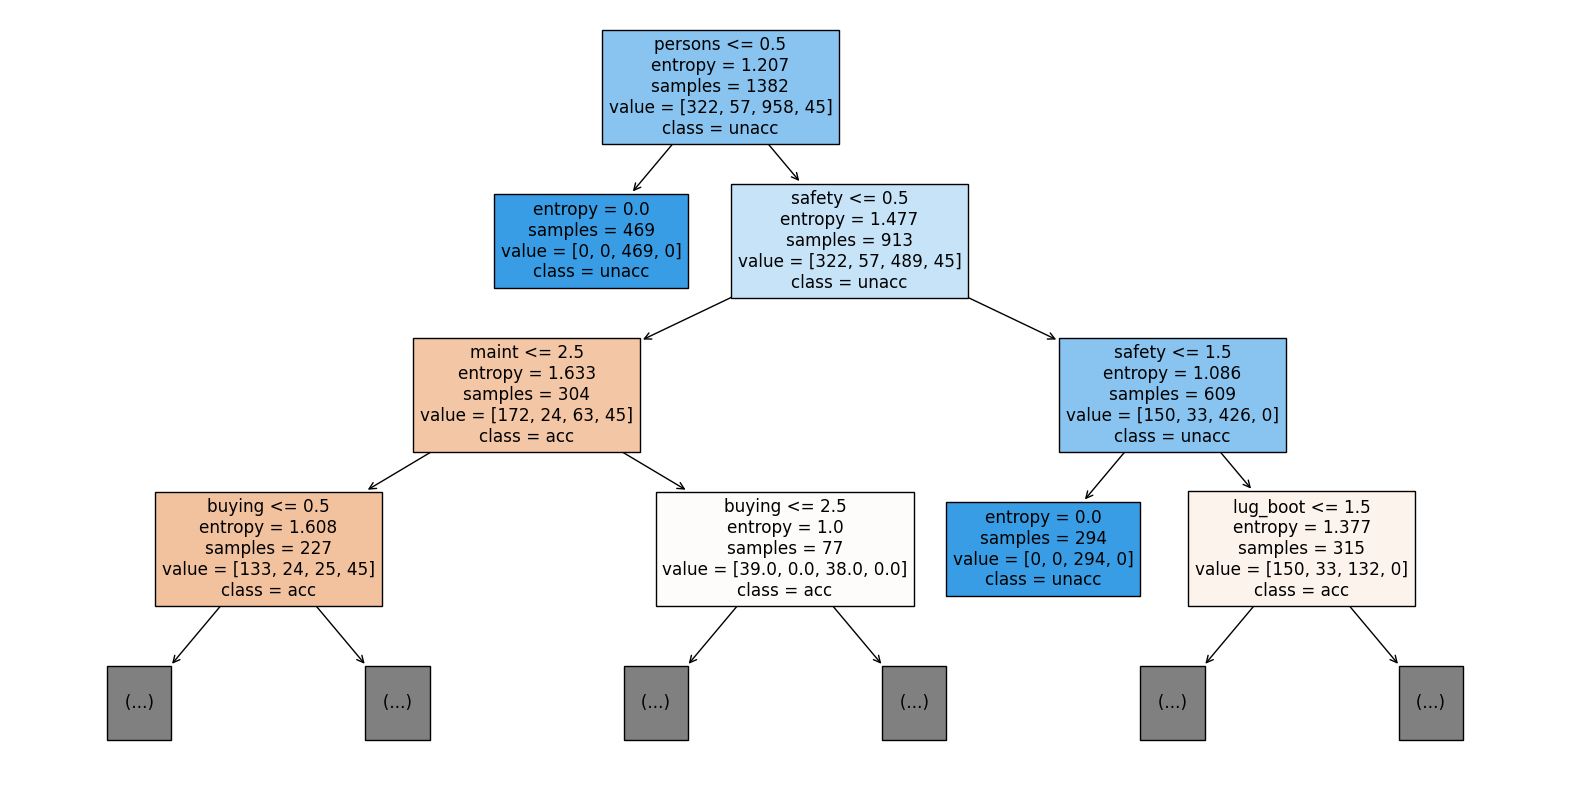

In [74]:
# 그리드 서칭 방식으로 최적의 하이퍼파라미터 찾기

param_grid = {
    'max_depth': range(3, 21, 2),
    'min_samples_split': range(2, 21, 2), # 노드의 최소 샘플 개수
    'min_samples_leaf': range(1, 6, 2), # 분할 이후의 리프의 최소 샘플 개수
    'max_leaf_nodes': range(10, 101, 5),
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random']
}

grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("최적 하이퍼 파라미터:", grid_search.best_params_)
print("최적 하이퍼 파라미터의 정확도:", grid_search.best_score_)

best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

print("최적 모델의 테스트 정확도:", accuracy_best) # 정확도가 소폭 증가했다 ! 

plt.figure(figsize=(20, 10))
plot_tree(best_dt, filled=True, feature_names=X.columns, class_names=np.unique(y).astype(str), max_depth=3)
plt.show()

In [75]:
# 디시전 트리의 분할 -> 노드마다 리프로 분할 -> 기본적으로 리프가 될수록 균일해져야 함 (엔트로피 감소, 지니계수 감소)

## 3. 다른 앙상블 모델 사용해보기

In [87]:
# TODO: Decision Tree가 아닌 다른 앙상블 모델에 훈련 데이터를 학습시켜서 테스트 데이터 정확도 확인
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # 랜덤 포레스트 앙상블

In [90]:
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

gbm_clf = GradientBoostingClassifier(random_state=42)
gbm_clf.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingClassifier(random_state=42)

In [91]:
y_pred_rf = rf_clf.predict(X_test)
y_pred_gbm = gbm_clf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_gbm = accuracy_score(y_test, y_pred_gbm)

# print(f"Accuracy = {accuracy_rf}")
# print(f"\nClassification report = {classification_report(y_test, y_pred_rf)}")

In [92]:
print(f"\nBase Classification report = \n {classification_report(y_test, y_pred)}")
print(f"\nHyperparameter tuned Classification report = \n {classification_report(y_test, y_pred_best)}")
print(f"\nRandom Forest Classification report = \n {classification_report(y_test, y_pred_rf)}")
print(f"\nGradient Boosting Model Classification report = \n {classification_report(y_test, y_pred_gbm)}")


Base Classification report = 
               precision    recall  f1-score   support

         acc       0.91      0.98      0.95        62
        good       1.00      0.75      0.86        12
       unacc       0.99      0.98      0.99       252
       vgood       1.00      1.00      1.00        20

    accuracy                           0.98       346
   macro avg       0.98      0.93      0.95       346
weighted avg       0.98      0.98      0.98       346


Hyperparameter tuned Classification report = 
               precision    recall  f1-score   support

         acc       0.94      0.98      0.96        62
        good       1.00      0.83      0.91        12
       unacc       0.99      0.98      0.99       252
       vgood       0.95      1.00      0.98        20

    accuracy                           0.98       346
   macro avg       0.97      0.95      0.96       346
weighted avg       0.98      0.98      0.98       346


Random Forest Classification report = 
          

In [93]:
print(f"\nBase Classification Acc = \n {accuracy_base}")
print(f"\nHyperparameter tuned Classification Acc = \n {accuracy_best}")
print(f"\nRandom Forest Classification Acc = \n {accuracy_rf}")
print(f"\nGradient Boosting Model Classficiation Acc = \n {accuracy_gbm}")


Base Classification Acc = 
 0.976878612716763

Hyperparameter tuned Classification Acc = 
 0.9797687861271677

Random Forest Classification Acc = 
 0.9682080924855492

Gradient Boosting Model Classficiation Acc = 
 0.976878612716763


## 최종 분석

1. 선택한 앙상블 모델에 대한 간단한 설명
2. 3가지 실행 정확도 결과에 대한 비교 분석

# 1. 선택한 앙상블 모델에 대한 간단한 설명

## 1.1. Random Forest

Random Forest는 Ensemble 방법론 중, Bagging (Bootstrapping Aggregation) 방법론에 해당.
Boostrapping은 복원 추출을 의미. 전체 데이터셋에서 고정된 크기의 데이터셋을 복원 추출하여, 추출된 데이터셋마다 개별 결정 트리가 학습됨.
복원 추출 방법으로, 어떤 데어터는 특정 모델에 들어가는 경우도 있고, 들어가지 않는 경우도 있어 모델의 다양성을 높이고, 일반화 능력이 증가되는 효과가 있음.

또한, Decision Tree의 노드가 분기될 때, 모든 feature를 고려하지 않고 랜덤하게 선택된 특정 feature만을 가지고 분류하여 모델의 다양성을 증가시킴. 

즉 Random Forest의 랜덤성은, 두가지로 부여됨.

1. Data Bootstrapping 
2. Feature Randomness 

이러한 랜덤성으로 인해 모델의 robustness가 증가하고, 성능이 증가하는 효과를 가짐.

## 1.2. Gradient Boosting Model

Gradient Boosting Model은 Ensemble 방법론 중, Boosting 방법론에 해당.
Boosting 방법론이란 패러렐하게 학습하는 bagging과 달리, sequential하게 학습을 진행함. 즉, weak learner가 잘못 분류했던 sample들을 분류하는데 더욱 집중하여 다음 모델이 학습하게 됨.
Boosting은 Bagging과 달리, weak learner들이 다 같은 데이터셋으로 학습하게 됨. 하지만 학습 과정이 시퀀설하게 진행되어 이전의 weak learner의 Residual Error를 학습하게 됨 (y-y_hat)

gradient boosting model은 이러한 boosting 계열의 모델 중, 학습을 경사하강으로 하는 모델을 일컬음

최종적인 strong learner는, 각 weak model들의 output을 가중치에 따라 가중합하여 구해짐.

역시나 GBM도 앙상블을 통해 성능을 높이기 위해 사용됨.

# 2. 3가지 실행 정확도 결과에 대한 비교분석

소수점 5쨰 자리에서 반올림 진행.

## Baseline Model Acc. = 0.9769 
## Tuned Model Acc. = 0.9798
## Random Forest Acc. = 0.9682
## Gradient Boosting Model Acc. = 0.9769

Tuned > Baseline = GBM > RF 순의 Acc. 달성

Ensemble Model보다 일반 Decision Tree의 성능이 높은 것은, Ensemble 모델의 경우 최적의 하이퍼파라피터를 탐색하지 않았고, Task의 난이도가 너무 쉬워 Acc.를 비교하기 애매한 것 때문으로 보임.